In [1]:
import numpy as np
from pathlib import Path
import os
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
from sklearn.model_selection import KFold
import os, json

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

In [2]:
def count_sign_changes(delta_x):
    signs = np.sign(delta_x)
    sign_changes = np.sum(np.diff(signs) != 0)
    return sign_changes

def is_bifurcation(delta_x_list):
    counts = [count_sign_changes(delta_x) for delta_x in delta_x_list]
    unique_counts = set(counts)
    return len(unique_counts) > 1


In [3]:
blablou

NameError: name 'blablou' is not defined

# Bifurcation Probability via Particle Density Estimation

In [ ]:
task = 'Active'
period = 'late'

# 1D range for threshold
thresh_range = np.linspace(0, 2, 100) # Increased resolution for a smoother 1D plot

for part in range(19, -1, -1):

    # load data
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=300, tmax=500)
        n_categories = len(list(state_train.keys()))
        categories = list(range(n_categories))

    # Input definition (same for all categories & trials)
    one_input = np.concatenate((np.zeros(75), np.ones(25), np.zeros(150)))
    input_train = {cat: np.stack([one_input for _ in range(state_train[cat].shape[0])]) for cat in categories}
    
    # load maximum likelihood parameters
    gainmodul_parent = lead.model.StratifiedGainModulation(tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
    gainmodul_parent.load_params(cwd.parents[0] / f'LEAD_ExperimentalFolder/Results_EEG_v2/{task}/{period}/GainModulatedModel_part{part}_params')
    
    # Grid search (1D loop)
    bif_list, ll_list = [], []
    for threshold in tqdm(thresh_range, desc=f"Part {part}"):
        
        # Fit gain and input_weight for this specific threshold
        ll_local = 0
        gainmodul = lead.model.StratifiedGainModulation(tau=gainmodul_parent.tau, process_noise=gainmodul_parent.process_noise, measure_noise=gainmodul_parent.measure_noise, threshold=threshold, sharpness=5)
        for cat in range(1, n_categories):
            gainmodul_one_cat = lead.model.GainModulation(tau=gainmodul_parent.tau, process_noise=gainmodul_parent.process_noise, measure_noise=gainmodul_parent.measure_noise, threshold=threshold, sharpness=5, 
                input_weight=getattr(gainmodul_parent, f'w{cat}'), gain=getattr(gainmodul_parent, f'g{cat}'))
            gainmodul_one_cat.fit(
                state_series={0: state_train[cat][:, 75:100]},
                input_series={0: input_train[cat][:, 75:100]},
                init_params=[getattr(gainmodul_one_cat, pname) for pname in gainmodul_one_cat._param_names],
                bounds=[(1,25), (0.01, 1), (0.01, 1), (0, 1), (0, 1), (0, 2), (0, 10)],
                fixed_params=['tau', 'process_noise', 'measure_noise', 'threshold', 'sharpness'])
            ll_local += gainmodul_one_cat.loglikelihood({0: state_train[cat][:, 75:100]}, {0: input_train[cat][:, 75:100]})
            gainmodul.set_params({f'w{cat}': gainmodul_one_cat.input_weight, f'g{cat}': gainmodul_one_cat.gain})
        ll_list.append(ll_local)
        
        # assess bifurcation with linear interpolation -> returns the bifurcation boolean
        states = np.linspace(-1,3,500)
        delta_x_list = []
        for cat in range(n_categories-1):
            delta_x_list.append(gainmodul.core(state=states, input_value=1, signal_category=cat)-states)
            w1, g1 = getattr(gainmodul, f'w{cat}'), getattr(gainmodul, f'g{cat}')
            w2, g2 = getattr(gainmodul, f'w{cat+1}'), getattr(gainmodul, f'g{cat+1}')
            # travel on the (w1, g1) -> (w2, g2) segment
            for t in np.linspace(0, 1, 100):
                w, g = w1 + t*(w2-w1), g1 + t*(g2-g1)
                model = lead.model.GainModulation(tau=gainmodul_parent.tau, process_noise=gainmodul_parent.process_noise, measure_noise=gainmodul_parent.measure_noise, threshold=threshold, sharpness=5, 
                        input_weight=w, gain=g)
                delta_x_list.append(model.core(state=states, input_value=1, signal_category=0)-states)
        bifbool = is_bifurcation(delta_x_list)
        bif_list.append(int(bifbool))

    # 1. Rescale Log-Likelihood to Likelihood
    ll_array = np.array(ll_list)
    likelihood = np.exp(ll_array - np.max(ll_array))
    bif_array = np.array(bif_list)

    # 2. Save 1D results
    save_path = cwd.parents[0] / f'LEAD_ExperimentalFolder/Results_EEG_v2/{task}/{period}/'
    np.savez(save_path / f'1D_grid_search_part{part}.npz', 
             threshold=thresh_range, 
             ll=ll_array, 
             likelihood=likelihood, 
             bifbool=bif_array)

    # Probability calc
    proba = np.average(bif_array, weights=likelihood)
    print(f'part{part} has a {proba} probability of bifurcation.')

    # 3. Plotting
    plt.figure(figsize=(10, 5))
    
    # Primary likelihood curve
    plt.plot(thresh_range, likelihood, color='black', linewidth=2, label='Likelihood')
    
    # Overlay markers where bifurcation == 1
    # We plot dots on the likelihood line only for indices where bif_array is True
    plt.scatter(thresh_range[bif_array], likelihood[bif_array], 
                color='red', s=40, label='Bifurcation Present', zorder=3)

    plt.title(f'Likelihood Profile for Threshold - Part{part} - Bifurcation Proba: {proba}')
    plt.xlabel('Threshold')
    plt.ylabel('Relative Likelihood')
    plt.grid(alpha=0.3)
    plt.legend()

    plt.savefig(save_path / f'1D_likelihood_part{part}_{task}.png')
    plt.close()

# Correct figures

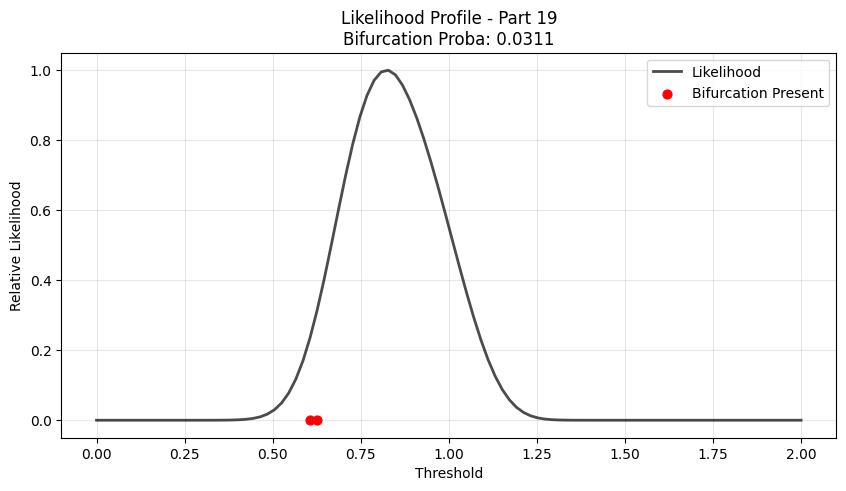

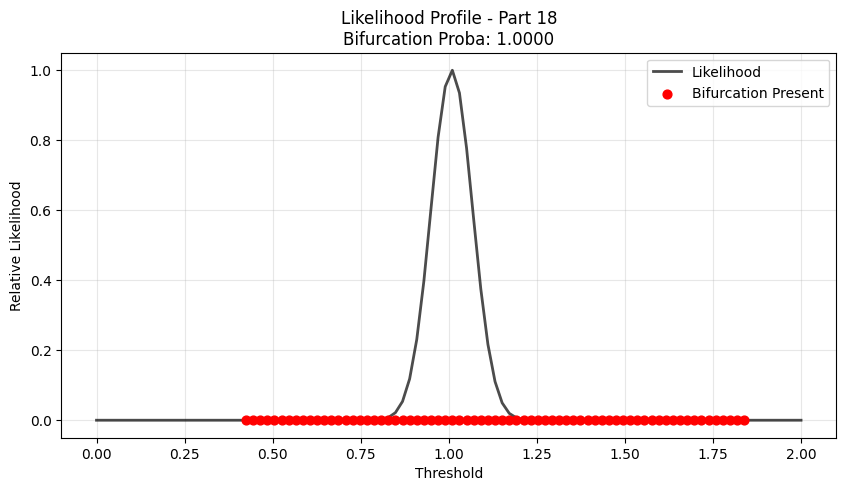

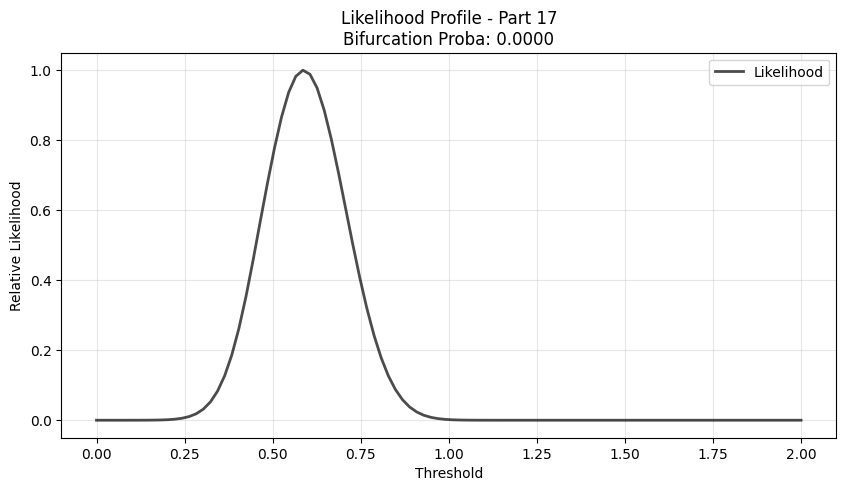

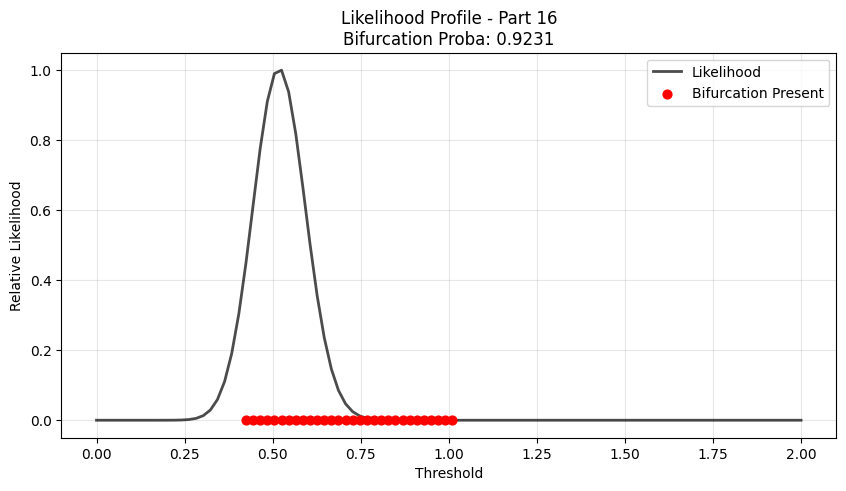

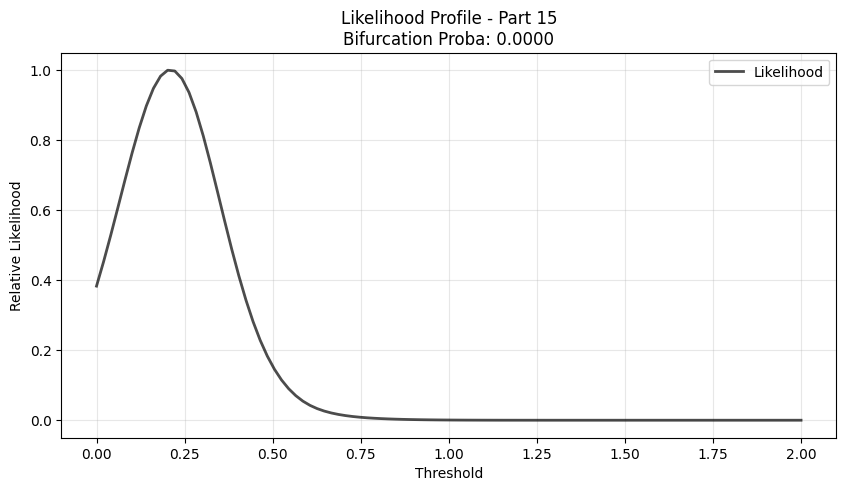

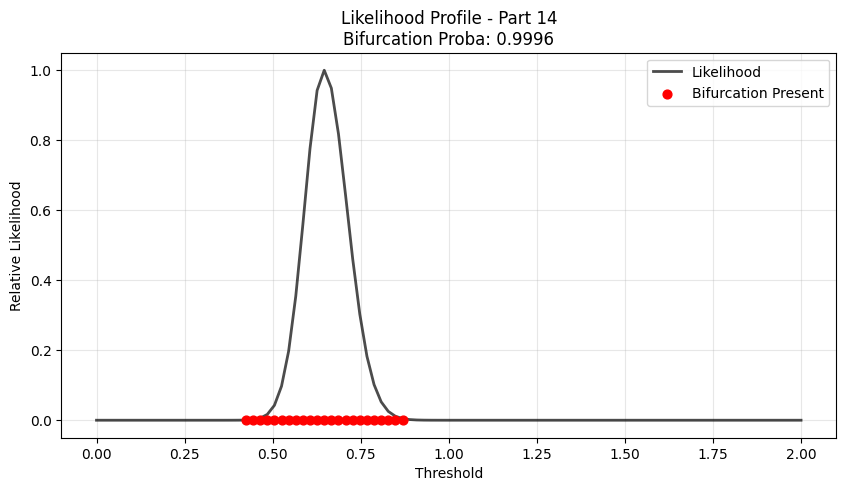

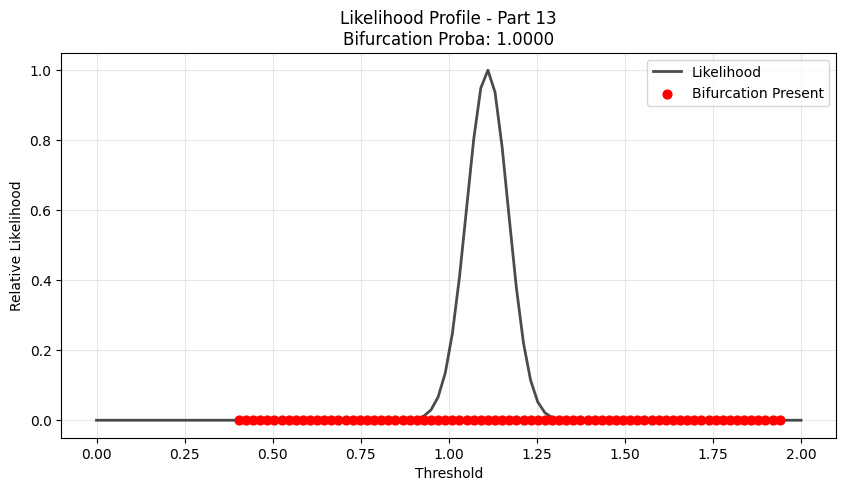

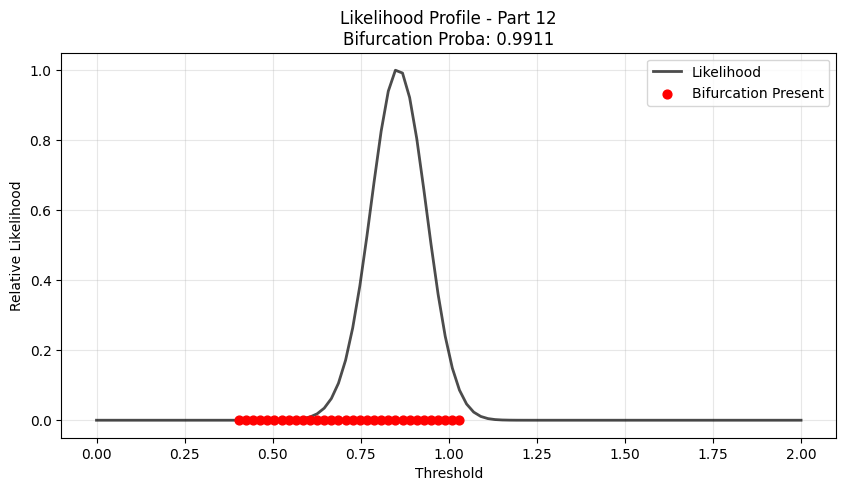

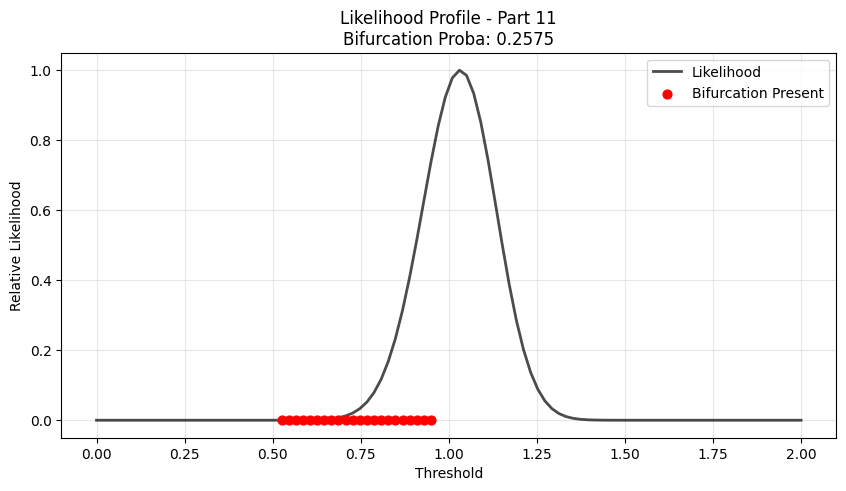

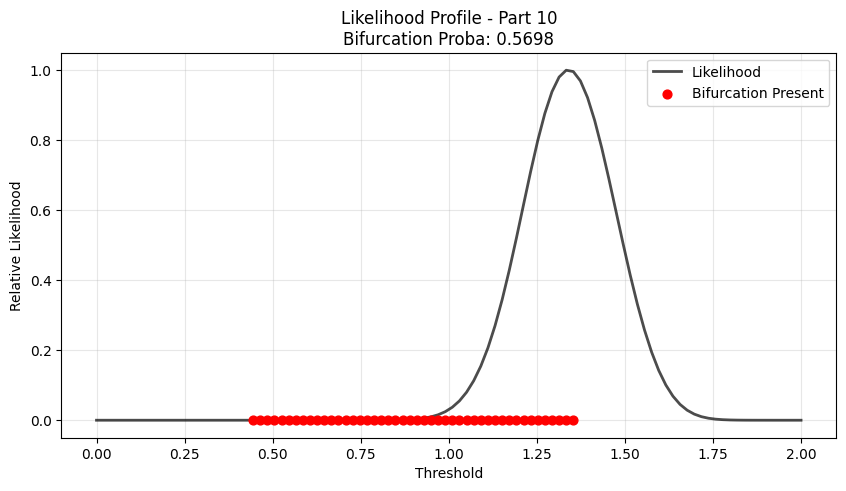

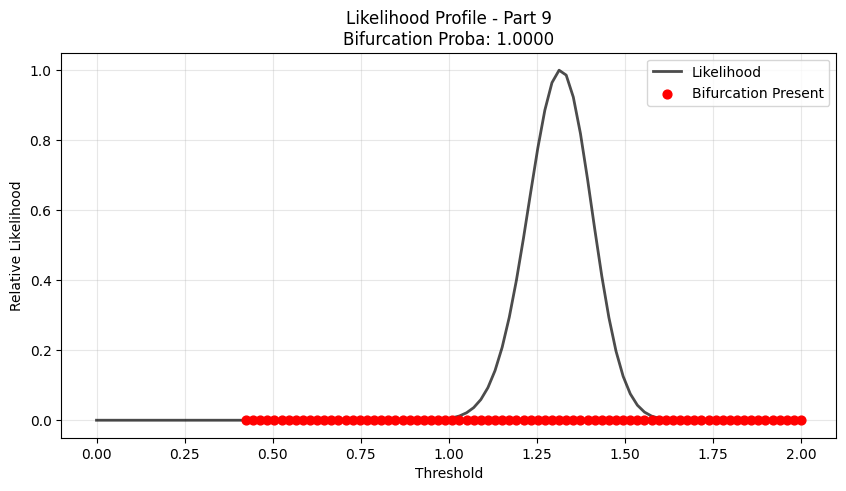

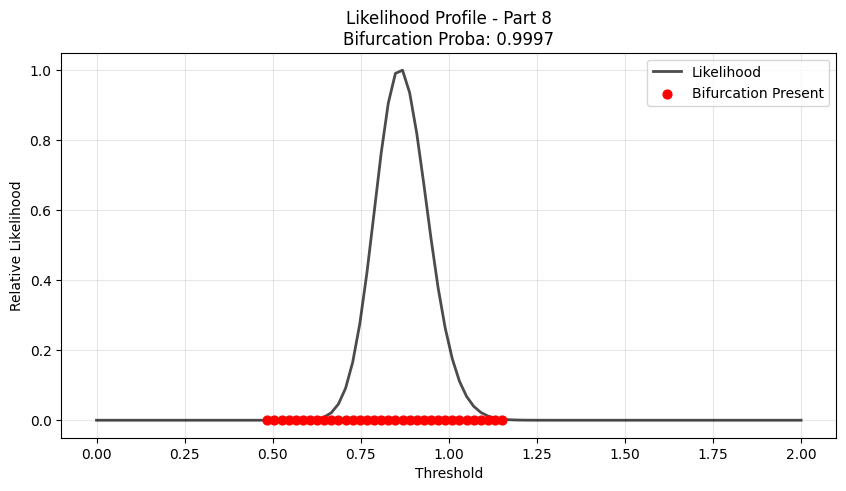

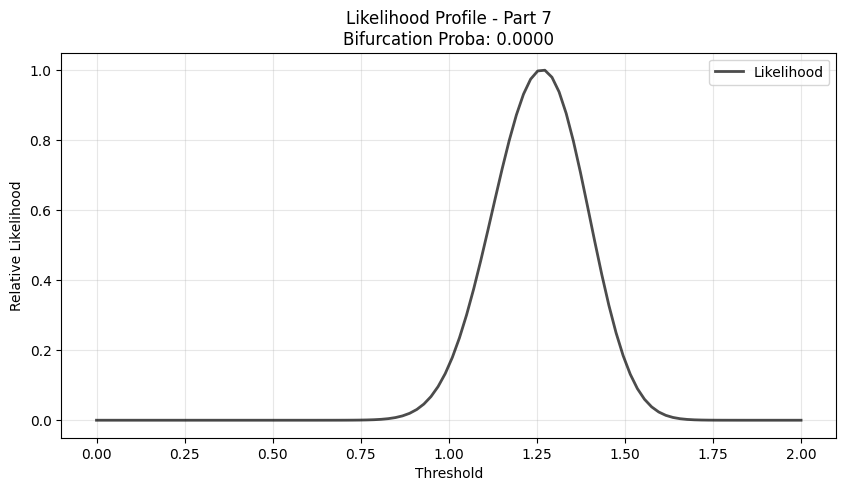

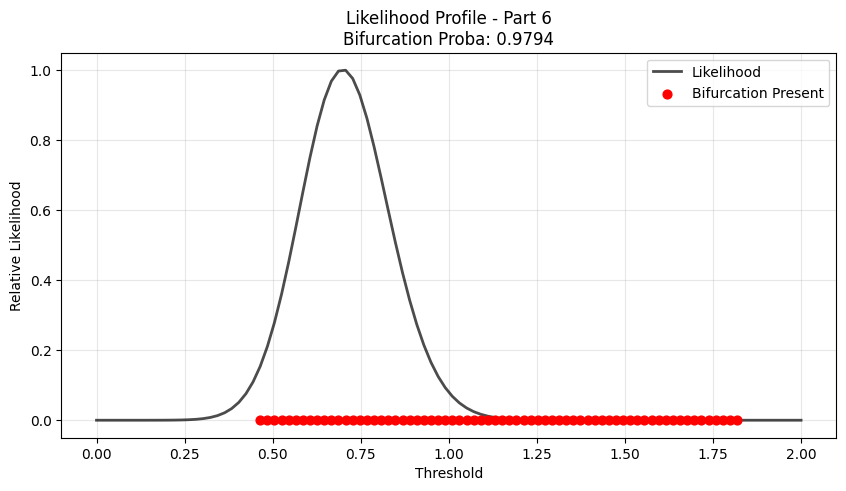

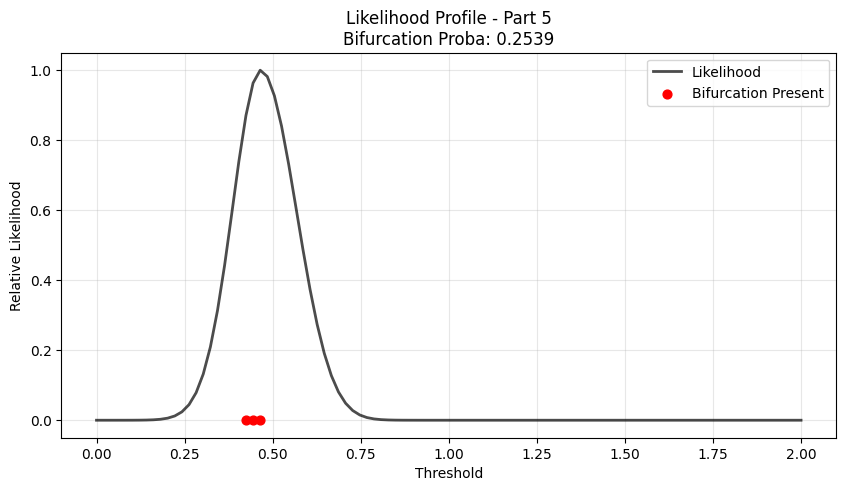

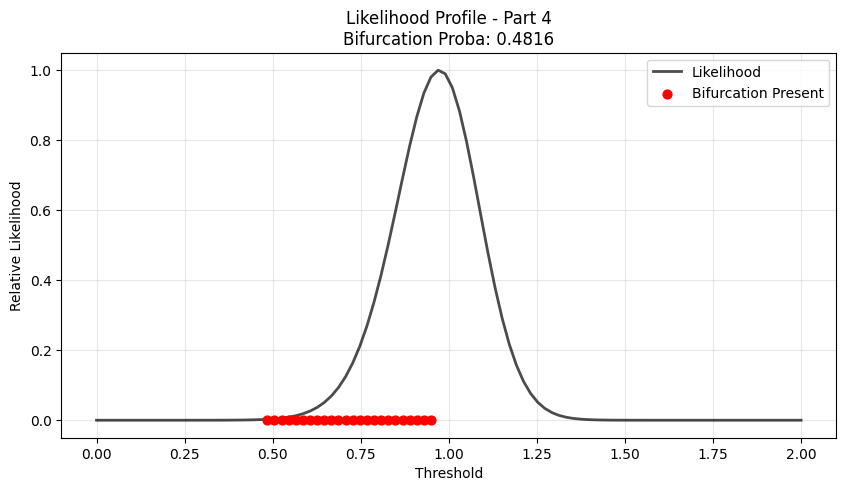

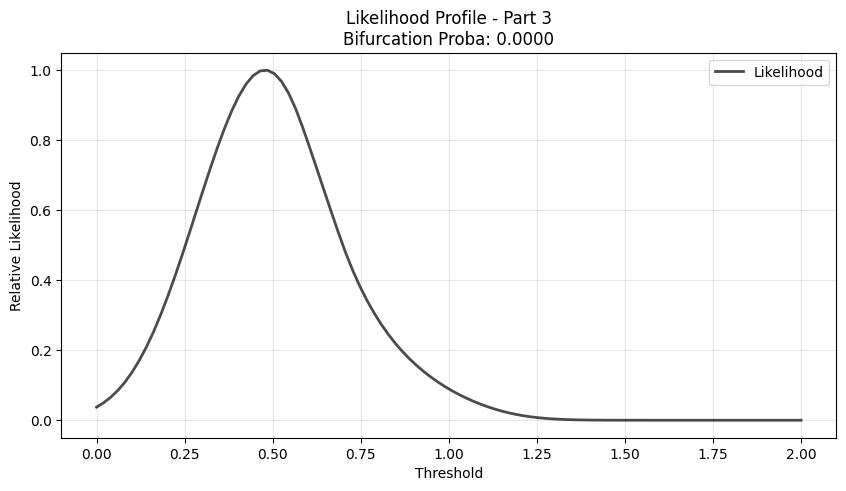

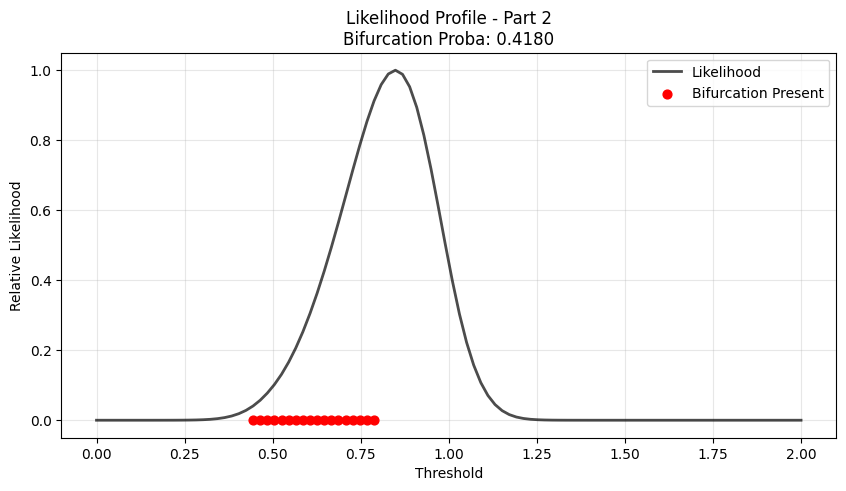

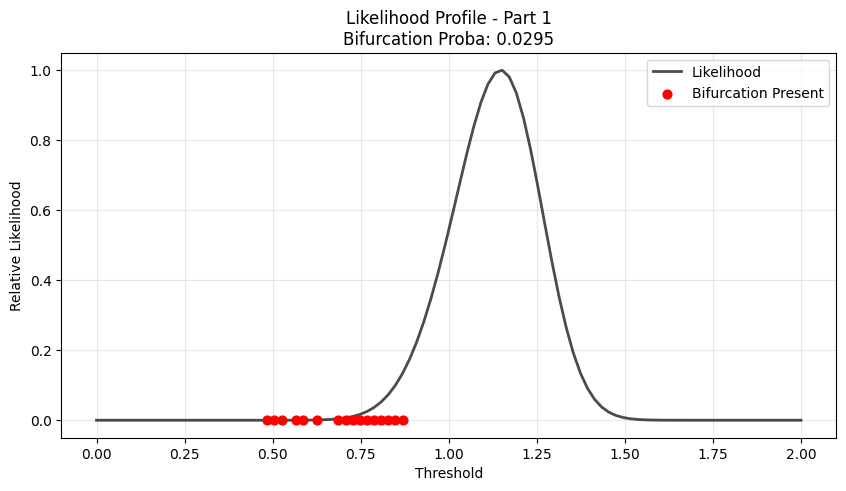

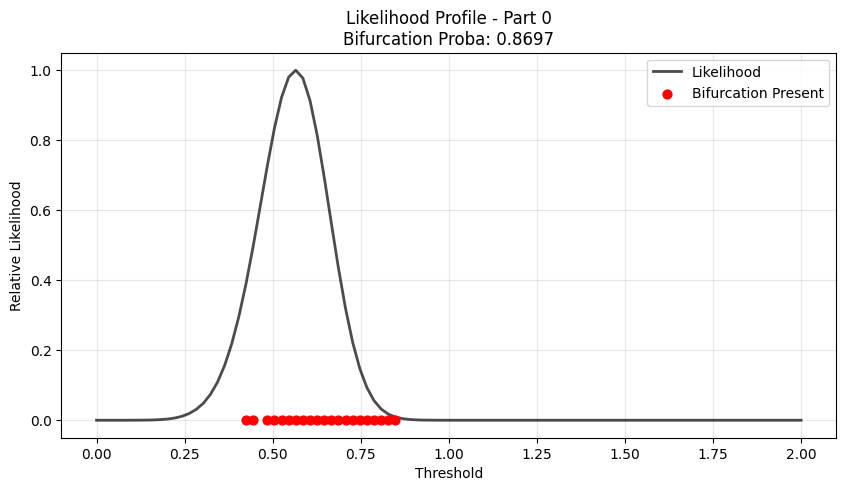

All plots updated.


In [7]:
# --- Configuration ---
task = 'Active'
period = 'late'
# Update 'cwd' to your actual base directory if this script is in a different folder
cwd = Path.cwd() 
save_path = cwd.parents[0] / f'LEAD_ExperimentalFolder/Results_EEG_v2/{task}/{period}/'

# Participants to process (matching your original 19 down to 0)
participants = range(19, -1, -1)

for part in participants:
    file_name = save_path / f'1D_grid_search_part{part}.npz'
    
    if not file_name.exists():
        print(f"Skipping Part {part}: File not found.")
        continue

    # 1. Load the data
    data = np.load(file_name)
    thresh_range = data['threshold']
    likelihood = data['likelihood']
    bif_array = data['bifbool']  # This is the 0s and 1s array

    # 2. Convert to Boolean Mask
    # This is the key fix: converting [0, 1, 0...] to [False, True, False...]
    bif_mask = bif_array.astype(bool)

    # 3. Recalculate Probability (for the title)
    proba = np.average(bif_array, weights=likelihood)

    # 4. Plotting
    plt.figure(figsize=(10, 5))
    
    # Plot the continuous likelihood curve
    plt.plot(thresh_range, likelihood, color='black', linewidth=2, label='Likelihood', alpha=0.7)
    
    # Overlay markers using the boolean mask
    # This only picks points where bif_mask is True
    if np.any(bif_mask):
        plt.scatter(thresh_range[bif_mask], 
                    np.zeros_like(thresh_range[bif_mask]), 
                    color='red', 
                    s=40, 
                    label='Bifurcation Present', 
                    zorder=3)

    plt.title(f'Likelihood Profile - Part {part}\nBifurcation Proba: {proba:.4f}')
    plt.xlabel('Threshold')
    plt.ylabel('Relative Likelihood')
    plt.grid(alpha=0.3)
    plt.legend()

    # Save the corrected figure
    plt.savefig(save_path / f'1D_likelihood_part{part}_{task}.png')
    plt.show()

print("All plots updated.")